---
# 0) Introduction
---

# The Quantum Fourier Transform (QFT)

The **Quantum Fourier Transform (QFT)** is the quantum analogue of the Discrete Fourier Transform (DFT). While the DFT operates on classical discrete signals, the QFT operates on quantum state amplitudes, providing an exponential speedup for specific tasks.

---

### 1. From Classical to Quantum
The classical **Discrete Fourier Transform (DFT)** is defined as:

$$
X[k] = \sum_{n=0}^{N-1} x[n] \, e^{-j 2\pi \frac{kn}{N}}, \quad k = 0, \dots, N-1
$$

The **Quantum Fourier Transform (QFT)** acts on a quantum basis state $\ket{x}$ and maps it to the state:

$$
\text{QFT}\ket{x} = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{j 2\pi \frac{xk}{N}} \ket{k}
$$

where $N = 2^n$ is the dimension of the Hilbert space for $n$ qubits.

---

### 2. Single Qubit Case ($n=1$)
For a single qubit ($N=2^1=2$), the QFT maps the state $\ket{x}$ to the Fourier basis $|\tilde{x}\rangle$. This operation is identical to the **Hadamard Gate** ($H$):

$$
\text{QFT}_1 \ket{x} = \frac{1}{\sqrt{2}} \sum_{k=0}^{1} e^{j 2\pi \frac{xk}{2}} \ket{k}
$$

Expanding this for $x \in \{0, 1\}$:
*   If $\ket{x} = \ket{0}$: $\text{QFT}\ket{0} = \frac{1}{\sqrt{2}}(\ket{0} + \ket{1})$
*   If $\ket{x} = \ket{1}$: $\text{QFT}\ket{1} = \frac{1}{\sqrt{2}}(\ket{0} - \ket{1})$

Thus, $\text{QFT}_1 = H = \frac{1}{\sqrt{2}} \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}$.

---

### 3. Extension to $n$ Qubits
To extend the transformation to a register of $n$ qubits, we utilize the **Product State Representation**. By representing $x$ in binary as $x_1 x_2 \dots x_n$, the state can be factored into a tensor product of $n$ single-qubit states:

$$
\text{QFT}_n \ket{x_1 x_2 \dots x_n} = \frac{1}{\sqrt{2^n}} \left(\ket{0} + e^{j 2\pi [0.x_n]}\ket{1}\right) \otimes \left(\ket{0} + e^{j 2\pi [0.x_{n-1}x_n]}\ket{1}\right) \otimes \dots \otimes \left(\ket{0} + e^{j 2\pi [0.x_1 x_2 \dots x_n]}\ket{1}\right)
$$

Where $[0.x_j x_{j+1} \dots x_n]$ represents the fractional binary notation:
$$
[0.x_j x_{j+1} \dots x_n] = \sum_{m=1}^{n-j+1} x_{j+m-1} 2^{-m}
$$

---

### 4. Matrix Representation
The QFT is a unitary matrix $QFT_N$. Letting $\omega = e^{j \frac{2\pi}{N}}$ be the $N$-th root of unity:

$$
QFT_N = \frac{1}{\sqrt{N}}
\begin{bmatrix}
1 & 1 & 1 & \cdots & 1 \\
1 & \omega & \omega^2 & \cdots & \omega^{N-1} \\
1 & \omega^2 & \omega^4 & \cdots & \omega^{2(N-1)} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & \omega^{N-1} & \omega^{2(N-1)} & \cdots & \omega^{(N-1)^2}
\end{bmatrix}
$$

---

### 5. Circuit Implementation Logic
The transformation is achieved physically using two primary gates:
1.  **Hadamard Gates ($H$):** To create superposition.
2.  **Controlled Phase Gates ($R_k$):** To encode the relative phases:
    $$
    R_k = \begin{bmatrix} 1 & 0 \\ 0 & e^{j \frac{2\pi}{2^k}} \end{bmatrix}
    $$

### 6. Applications
The QFT is a key building block in algorithms providing exponential speedups:
*   **Shor’s Algorithm:** Integer factorization.
*   **Quantum Phase Estimation:** Finding eigenvalues of unitary operators.
*   **Period Finding:** Identifying hidden patterns in functions.

---
# 1) Dependency Installation
---

In [239]:
#!pip install qiskit qiskit-aer qiskit-ibm-runtime numpy scipy matplotlib seaborn pandas ipywidgets pylatexenc tqdm qiskit[visualization]
# Uncomment to install the dependencies

---
# 2) Algorithm implementation and utilities
---

## 2.1) Imports

In [240]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Qiskit Core & Circuitry
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit.quantum_info import Statevector

# Transpilation & Optimization
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Simulation & Noise Modeling
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# IBM Runtime & Primitives
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

# Visualization
from qiskit.visualization import plot_histogram, plot_bloch_multivector

## 2.2) QTF Implementation

In [241]:
def qft(qc_qft, n_qubit):
    for i in range(n_qubit):
        # Apply Hadamard gate to qubit i (creates superposition)
        qc_qft.h(i)

        # Apply controlled phase rotations from qubits j > i to qubit i
        for j in range(i + 1, n_qubit):
            # Compute the rotation angle (decreases exponentially with distance)
            angle = np.pi / (2 ** (j - i))

            # Apply controlled phase gate:
            # control qubit = j, target qubit = i
            qc_qft.cp(angle, j, i)

    # Swap qubits to reverse their order (QFT outputs reversed bit order)
    for i in range(n_qubit // 2):
        qc_qft.swap(i, n_qubit - i - 1)

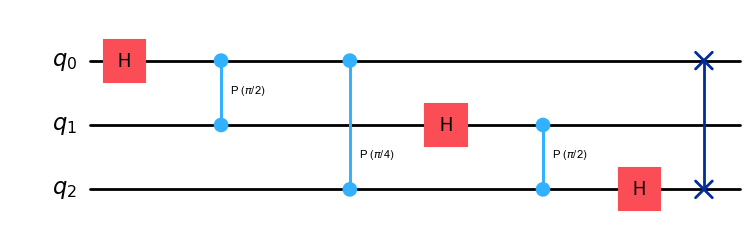

In [242]:
n = 3
qc = QuantumCircuit(n)
qft(qc, n)
qc.draw(output="mpl", filename="./images/approx_qft_nqubit.svg")

### Implementation Notes: a bit Ordering and Logic

This implementation demonstrates that we are treating $q_0$ as the **least significant bit (LSB)**, consistent with Qiskit's little-endian convention. As seen in the circuit logic above, we apply the transformations in a specific order to satisfy the product state decomposition of the QFT:

*   **Sequential Processing**: We apply the **Hadamard gate** and successive **controlled-phase rotations** starting from $q_0$ and moving toward the higher-index qubits.
*   **Phase Logic**: The first qubit processed, $q_0$, receives the most rotations (e.g., $P(\pi/2)$ and $P(\pi/4)$ in a 3-qubit system). This is because it must incorporate the relative phase information from all subsequent qubits to represent the most granular part of the fractional binary sum.
*   **A bit of Reversal (The SWAP Stage)**: Because the QFT algorithm naturally outputs results in a reversed order relative to the input bitstring, we conclude the operation with **SWAP gates**. This ensures that the state of $q_0$ at the end of the circuit correctly corresponds to the LSB of the Fourier-transformed state, aligning the mathematical result with Qiskit's internal qubit mapping.

## 2.3) IQFT Implementation

In [243]:
def inverse_qft(qc_iqft, n_qubit):
    # Undo the final qubit order reversal of QFT
    for i in range(n_qubit // 2):
        qc_iqft.swap(i, n_qubit - i - 1)

    # Apply inverse rotations and Hadamard gates in reverse order
    for i in reversed(range(n_qubit)):
        # Apply inverse controlled phase rotations
        for j in reversed(range(i + 1, n_qubit)):
            angle = -np.pi / (2 ** (j - i))  # negative angle = inverse rotation
            qc_iqft.cp(angle, j, i)

        # Apply Hadamard (self-inverse)
        qc_iqft.h(i)

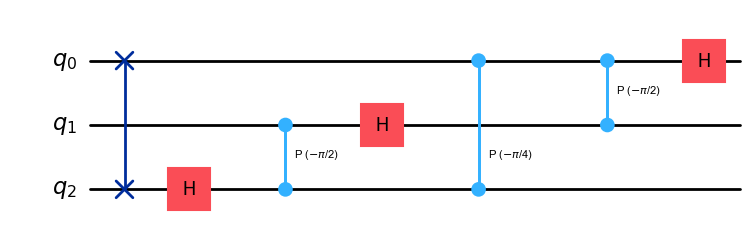

In [244]:
n = 3
qc = QuantumCircuit(n)
inverse_qft(qc, n)
qc.draw(output="mpl", filename="./images/iqft_nqubit.svg")

## 2.4) Approximated QFT

In [245]:
def qft_approx(qc_approx_qft, n_qubit, threshold=0.1):
    for i in range(n_qubit):
        # Create superposition on qubit i
        qc_approx_qft.h(i)

        for j in range(i + 1, n_qubit):
            # Compute controlled phase rotation angle
            angle = np.pi / (2 ** (j - i))

            # Apply rotation only if it is not too small
            if angle > threshold:
                qc_approx_qft.cp(angle, j, i)

    # Reverse qubit order (QFT outputs reversed bit ordering)
    for i in range(n_qubit // 2):
        qc_approx_qft.swap(i, n_qubit - i - 1)

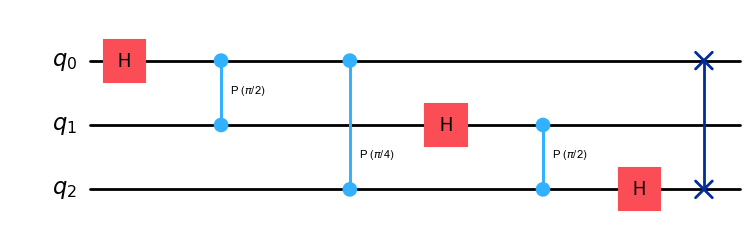

In [246]:
n = 3
qc = QuantumCircuit(n)
qft_approx(qc, n)
qc.draw(output="mpl", filename="./images/approx_qft_nqubit.svg")

## Utility Functions

In [247]:
def run_circuit(compiled, simulator):
    # Execute the compiled circuit on the simulator
    result_computation = simulator.run(compiled, shots=1024).result()

    # Return measurement counts
    return result_computation.get_counts()


def normalize(counts: dict) -> dict:
    # Ensure numerical stability by casting to float
    total = float(sum(counts.values()))

    # Return probability distribution
    return {k: float(v) / total for k, v in counts.items()}


def l1_distance(p, q):
    # Union of all observed outcomes
    keys = set(p) | set(q)

    # Compute total variation distance (L1 / 2)
    return 0.5 * sum(abs(p.get(k, 0) - q.get(k, 0)) for k in keys)


def create_noise_model(p1=0.01, p2=0.02):
    # Initialize noise model
    noise_model_inner = NoiseModel()

    # Single-qubit depolarizing error
    error_1q = depolarizing_error(p1, 1)

    # Two-qubit depolarizing error
    error_2q = depolarizing_error(p2, 2)

    # Apply noise to specific gates
    noise_model_inner.add_all_qubit_quantum_error(error_1q, ['h'])
    noise_model_inner.add_all_qubit_quantum_error(error_2q, ['cp', 'cx'])

    return noise_model_inner


def measure_time(qc_inner, simulator):
    # Start timing
    start = time.time()

    # Compile circuit for backend
    compiled = transpile(qc_inner, simulator)

    # Run simulation (blocking until completion)
    simulator.run(compiled, shots=1024).result()

    # Return elapsed time
    return time.time() - start

def get_circuit_data(qc_inner, name):
    """Helper function to extract stats into a dictionary."""
    ops = qc_inner.count_ops()
    return {
        "Implementation": name,
        "Depth": qc_inner.depth(),
        "Total Gates": sum(ops.values()),
        "Gate Breakdown": str(dict(ops))
    }

---
# 3) Tests
---

In [248]:
# Connect to IBM Quantum
load_dotenv()  # loads .env file
service = QiskitRuntimeService(
    channel="ibm_cloud",
    token=os.getenv("API_KEY")
)

# Select least busy real backend
backend = service.least_busy(simulator=False, operational=True)

# Number of qubits
n = 3

# Ideal simulator
sim = AerSimulator()

# Noise model derived from real backend
noise_model = NoiseModel.from_backend(backend)

# Noisy simulator based on backend characteristics
sim_noise = AerSimulator.from_backend(backend)

qiskit_runtime_service._discover_account:WARNING:2026-05-03 18:28:22,606: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-03 18:28:26,885: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-03 18:28:27,479: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-03 18:28:29,824: Using instance: open-instance, plan: open


## 3.1) Soundness Test (QFT⁻¹ ∘ QFT)

Soundness test (should recover |010>): {'010': 1024}
Cascading QFT and Inverse QFT Circuit:


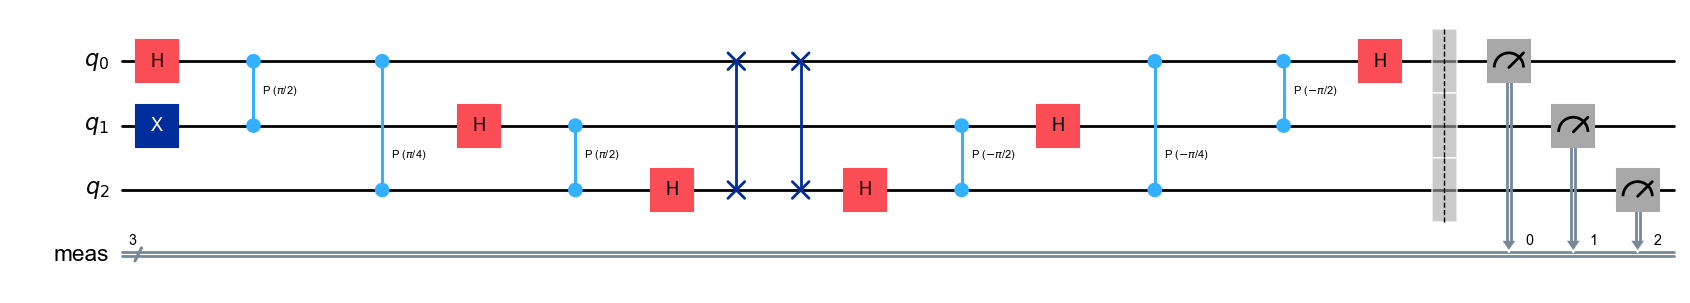

In [249]:
# Create a quantum circuit with n qubits
qc_sound = QuantumCircuit(n)

# Prepare basis state |010> by flipping qubit 1
qc_sound.x(1)

# Apply Quantum Fourier Transform
qft(qc_sound, n)

# Apply inverse QFT to recover the original state
inverse_qft(qc_sound, n)

# Measure all qubits
qc_sound.measure_all()

# Run the circuit on an ideal simulator
counts_sound = run_circuit(qc_sound, sim)

# Print results of the soundness test
print("Soundness test (should recover |010>):", counts_sound)

print("Cascading QFT and Inverse QFT Circuit:")
qc_sound.draw(output='mpl', filename="/images/soundness_test.svg")

## 3.2) Basic test on Aer simulator (Ideal vs Noisy)

### Preparation of the initial state of computation

Initialization circuit:


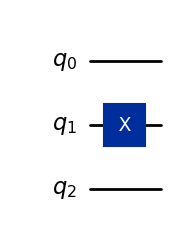

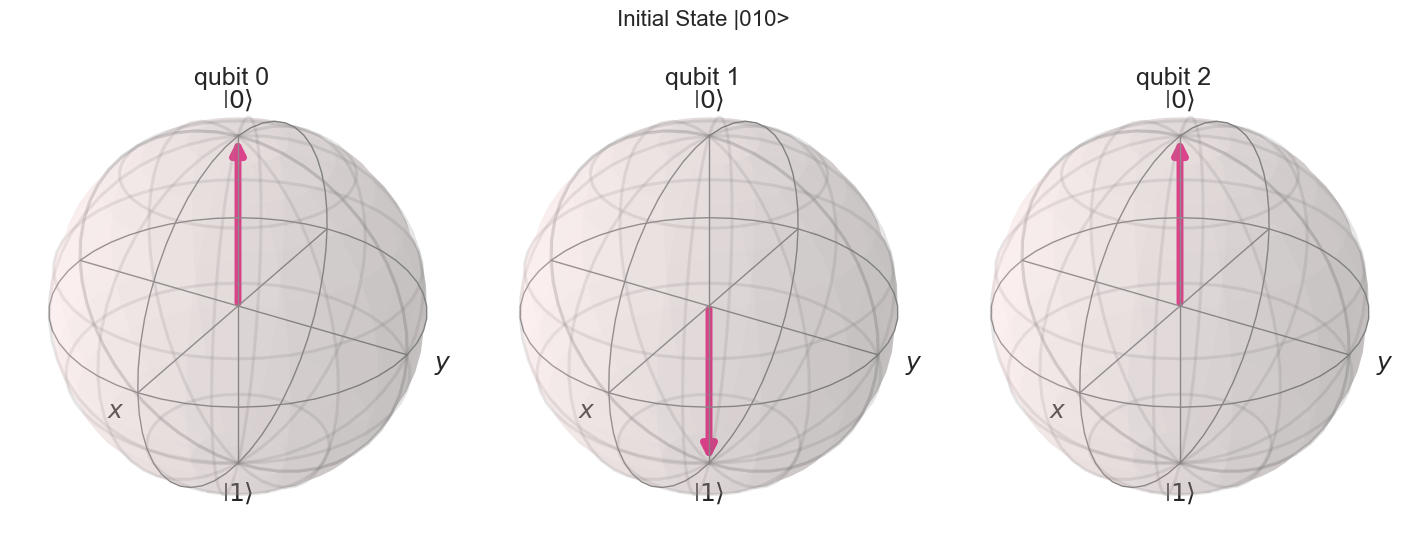

In [250]:
qc = QuantumCircuit(n)
qc.x(1) # Prepare basis state |010> by applying X gate on qubit 1

# Drawing the initialization circuit
print("Initialization circuit:")
display(qc.draw(output="mpl", filename="/images/3qubit_init.svg"))

# Printing the initial state
state_init = Statevector.from_instruction(qc)
display(plot_bloch_multivector(state_init, title="Initial State |010>"))

In [251]:
# Apply Quantum Fourier Transform
qft(qc, n)

#### Printing the new state in the Fourier Basis

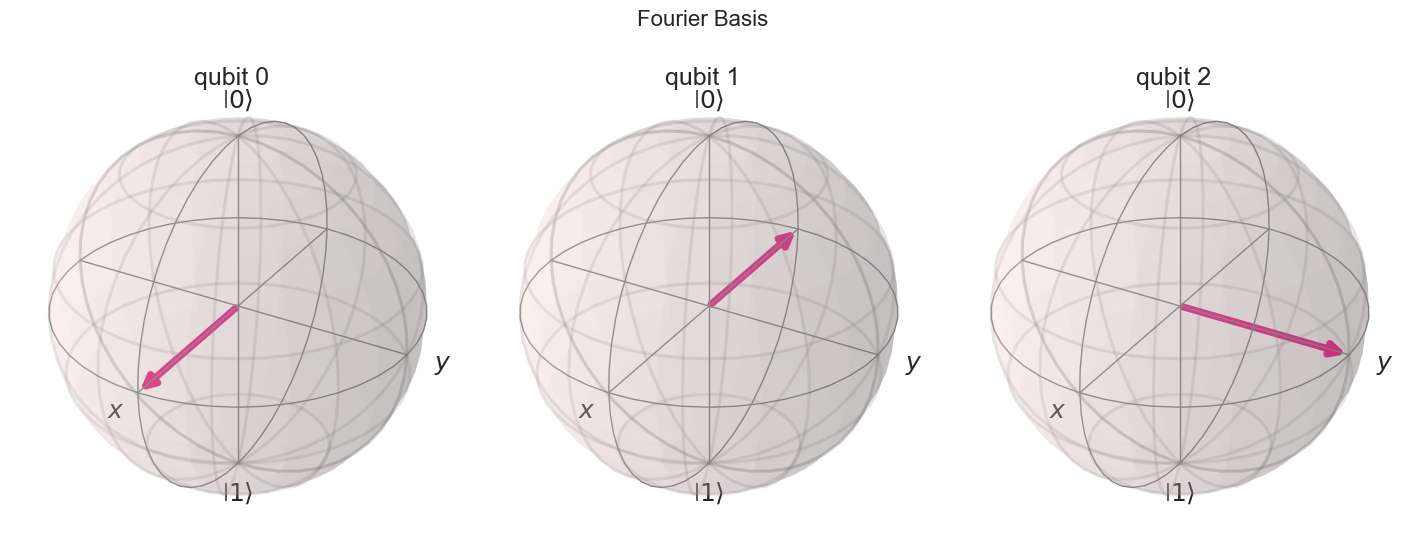

In [252]:
qc_ideal_view = qc.copy()
state_fourier = Statevector.from_instruction(qc_ideal_view)
display(plot_bloch_multivector(state_fourier, title="Fourier Basis"))

#### Printing the QFT Circuit

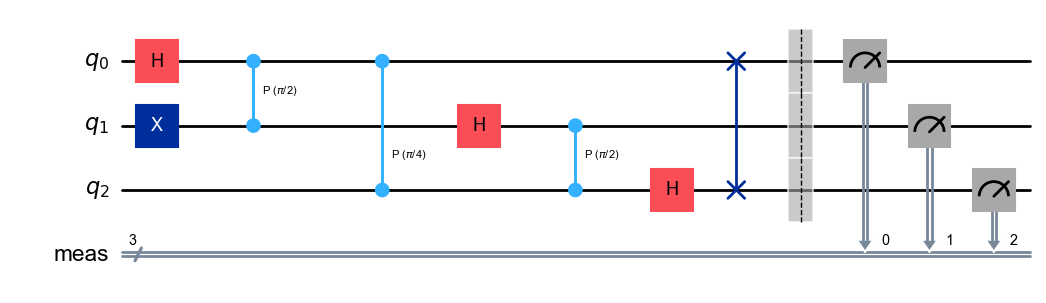

In [253]:
# Measure all qubits
qc.measure_all()

# Drawing the circuit
qc.draw(output="mpl", filename="/images/qft_3qubit.svg")

### Ideal VS Noisy Executions

In [254]:
# Transpile and Run (ideal vs noisy)
qc_no_noise = transpile(qc, backend=sim)
qc_noise = transpile(qc, backend=sim_noise)

counts_ideal = run_circuit(qc_no_noise, sim)
counts_noise = run_circuit(qc_noise, sim_noise)

# Convert raw counts to probability distributions
p_ideal = normalize(counts_ideal)
p_noise = normalize(counts_noise)

# Compute L1 distance between ideal and noisy distributions
error_noise = l1_distance(p_ideal, p_noise)

In [255]:
all_states = sorted(set(counts_ideal.keys()).union(set(counts_noise.keys())))

comparison_data = []
for state in all_states:
    comparison_data.append({
        "State": state,
        "Ideal Counts": counts_ideal.get(state, 0),
        "Noisy Counts": counts_noise.get(state, 0),
        "Ideal Prob": p_ideal.get(state, 0.0),
        "Noisy Prob": p_noise.get(state, 0.0),
        "Delta (Abs)": abs(p_ideal.get(state, 0.0) - p_noise.get(state, 0.0))
    })

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison.style.background_gradient(subset=['Delta (Abs)'], cmap='Reds'))

print(f"Validation Analysis: Ideal QFT vs. Noisy QFT")
print(f"Backend Analysis: {backend.name}")
print(f"Total L1 Distance (Error): {error_noise:.4f}\n")

,State,Ideal Counts,Noisy Counts,Ideal Prob,Noisy Prob,Delta (Abs)
0,000,128,125,0.125000,0.122070,0.002930
1,001,118,125,0.115234,0.122070,0.006836
2,010,138,134,0.134766,0.130859,0.003906
3,011,123,136,0.120117,0.132812,0.012695
4,100,126,126,0.123047,0.123047,0.000000
5,101,119,118,0.116211,0.115234,0.000977
6,110,133,111,0.129883,0.108398,0.021484
7,111,139,149,0.135742,0.145508,0.009766


Validation Analysis: Ideal QFT vs. Noisy QFT
Backend Analysis: ibm_fez
Total L1 Distance (Error): 0.0293



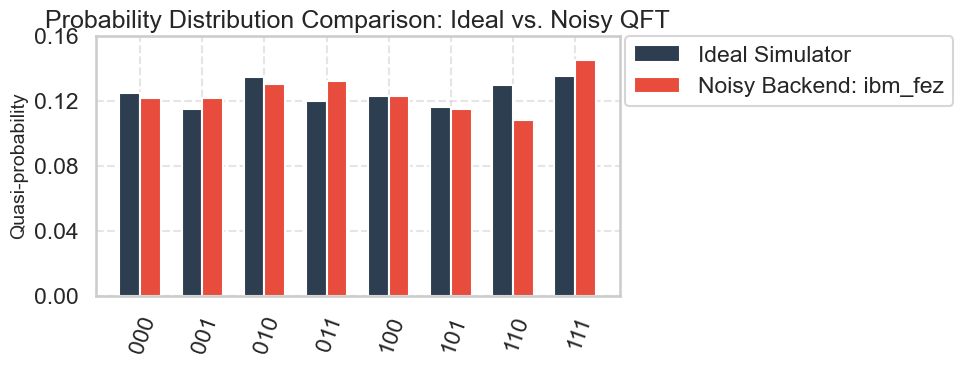

In [256]:
data_to_plot = [p_ideal, p_noise]
labels = ['Ideal Simulator', f'Noisy Backend: {backend.name}']

fig = plot_histogram(
    data_to_plot,
    legend=labels,
    color=['#2c3e50', '#e74c3c'],
    title="Probability Distribution Comparison: Ideal vs. Noisy QFT",
    figsize=(10, 4),
    bar_labels=False
)

display(fig)

## 3.3) Library vs Manual

In [257]:
qc_lib = QuantumCircuit(n)

# Prepare basis state |010>
qc_lib.x(1)

# Apply built-in QFT gate from Qiskit library
qc_lib.append(QFTGate(n), range(n))

# Measure all qubits
qc_lib.measure_all()

# Transpile for ideal simulator
qc_lib = transpile(qc_lib, sim)

# Run simulation
counts_lib = run_circuit(qc_lib, sim)

# Convert to probability distribution
p_lib = normalize(counts_lib)

# Compare with ideal distribution using L1 distance
error_lib = l1_distance(p_ideal, p_lib)

In [258]:
all_states = sorted(set(counts_ideal.keys()).union(set(counts_lib.keys())))

comparison_data = []
for state in all_states:
    comparison_data.append({
        "State": state,
        "Ideal Counts": counts_ideal.get(state, 0),
        "Library Counts": counts_lib.get(state, 0),
        "Ideal Prob": p_ideal.get(state, 0.0),
        "Library Prob": p_lib.get(state, 0.0),
        "Delta (Abs)": abs(p_ideal.get(state, 0.0) - p_lib.get(state, 0.0))
    })

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison.style.background_gradient(subset=['Delta (Abs)'], cmap='Reds'))

print(f"Validation Analysis: Custom QFT vs. Qiskit Library")
print(f"Total L1 Distance (Error): {error_lib:.4f}\n")

,State,Ideal Counts,Library Counts,Ideal Prob,Library Prob,Delta (Abs)
0,000,128,132,0.125000,0.128906,0.003906
1,001,118,114,0.115234,0.111328,0.003906
2,010,138,117,0.134766,0.114258,0.020508
3,011,123,137,0.120117,0.133789,0.013672
4,100,126,116,0.123047,0.113281,0.009766
5,101,119,146,0.116211,0.142578,0.026367
6,110,133,124,0.129883,0.121094,0.008789
7,111,139,138,0.135742,0.134766,0.000977


Validation Analysis: Custom QFT vs. Qiskit Library
Total L1 Distance (Error): 0.0439



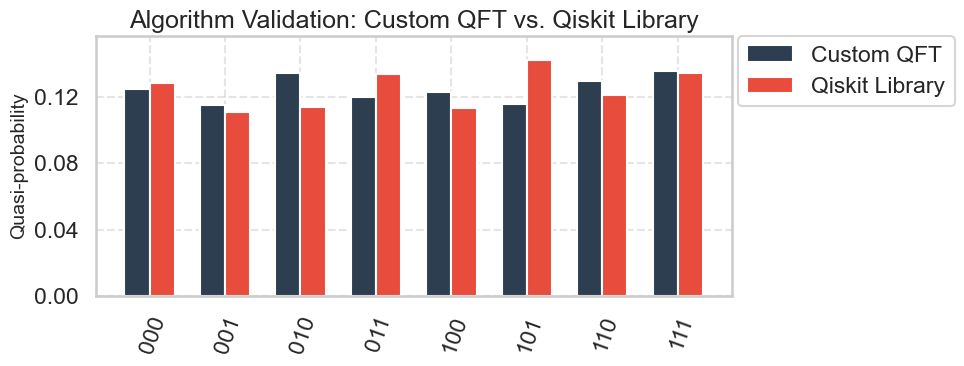

In [259]:
data_to_plot = [p_ideal, p_lib]
labels = ['Custom QFT', 'Qiskit Library']

fig = plot_histogram(
    data_to_plot,
    legend=labels,
    color=['#2c3e50', '#e74c3c'],
    title="Algorithm Validation: Custom QFT vs. Qiskit Library",
    figsize=(10, 4),
    bar_labels=False
)

display(fig)

## 3.4) Approximate QFT

In [260]:
qc_approx = QuantumCircuit(n)

# Prepare basis state |010>
qc_approx.x(1)

# Apply approximate QFT (small rotations are dropped)
qft_approx(qc_approx, n, threshold=0.2)

# Measure all qubits
qc_approx.measure_all()

# Run on ideal simulator
counts_approx = run_circuit(qc_approx, sim)

# Convert to probability distribution
p_approx = normalize(counts_approx)

# Compare approximate QFT with noisy distribution
error_approx = l1_distance(p_noise, p_approx)

In [261]:
all_states = sorted(set(counts_ideal.keys()).union(set(counts_approx.keys())))

comparison_data = []
for state in all_states:
    comparison_data.append({
        "State": state,
        "Ideal Counts": counts_ideal.get(state, 0),
        "Library Counts": counts_approx.get(state, 0),
        "Ideal Prob": p_ideal.get(state, 0.0),
        "Library Prob": p_approx.get(state, 0.0),
        "Delta (Abs)": abs(p_ideal.get(state, 0.0) - p_approx.get(state, 0.0))
    })

df_comparison = pd.DataFrame(comparison_data)
display(df_comparison.style.background_gradient(subset=['Delta (Abs)'], cmap='Reds'))

print(f"Approximation Analysis: Full QFT vs. Approximate QFT (threshold=0.2)")
print(f"Total L1 Distance (Error): {error_approx:.4f}\n")

,State,Ideal Counts,Library Counts,Ideal Prob,Library Prob,Delta (Abs)
0,000,128,121,0.125000,0.118164,0.006836
1,001,118,130,0.115234,0.126953,0.011719
2,010,138,134,0.134766,0.130859,0.003906
3,011,123,122,0.120117,0.119141,0.000977
4,100,126,127,0.123047,0.124023,0.000977
5,101,119,130,0.116211,0.126953,0.010742
6,110,133,117,0.129883,0.114258,0.015625
7,111,139,143,0.135742,0.139648,0.003906


Approximation Analysis: Full QFT vs. Approximate QFT (threshold=0.2)
Total L1 Distance (Error): 0.0234



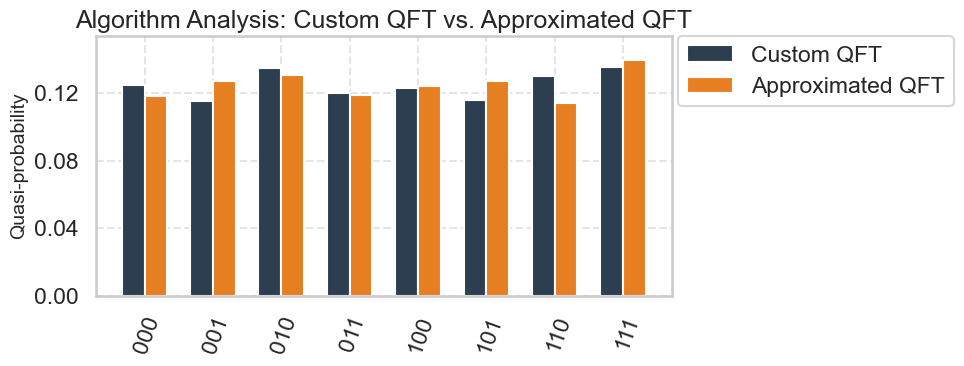

In [262]:
data_to_plot = [p_ideal, p_approx]
labels = ['Custom QFT', 'Approximated QFT']

fig = plot_histogram(
    data_to_plot,
    legend=labels,
    color=['#2c3e50', '#e67e22'],
    title="Algorithm Analysis: Custom QFT vs. Approximated QFT",
    figsize=(10, 4),
    bar_labels=False
)

display(fig)

## 3.5) Error Comparison Summary

In [263]:
error_data = [
    {"Implementation": "Hardware Noise", "Metric": "Total Variation (L1)", "Error Value": error_noise},
    {"Implementation": "Approximate QFT", "Metric": "Truncation Error", "Error Value": error_approx},
    {"Implementation": "Library QFT", "Metric": "Implementation Discrepancy", "Error Value": error_lib}
]

df_errors = pd.DataFrame(error_data)

print("--- Error Summary Analysis ---")
display(df_errors.style.format({"Error Value": "{:.6f}"})
                 .background_gradient(subset=["Error Value"], cmap="Reds"))

--- Error Summary Analysis ---


,Implementation,Metric,Error Value
0,Hardware Noise,Total Variation (L1),0.029297
1,Approximate QFT,Truncation Error,0.023438
2,Library QFT,Implementation Discrepancy,0.043945


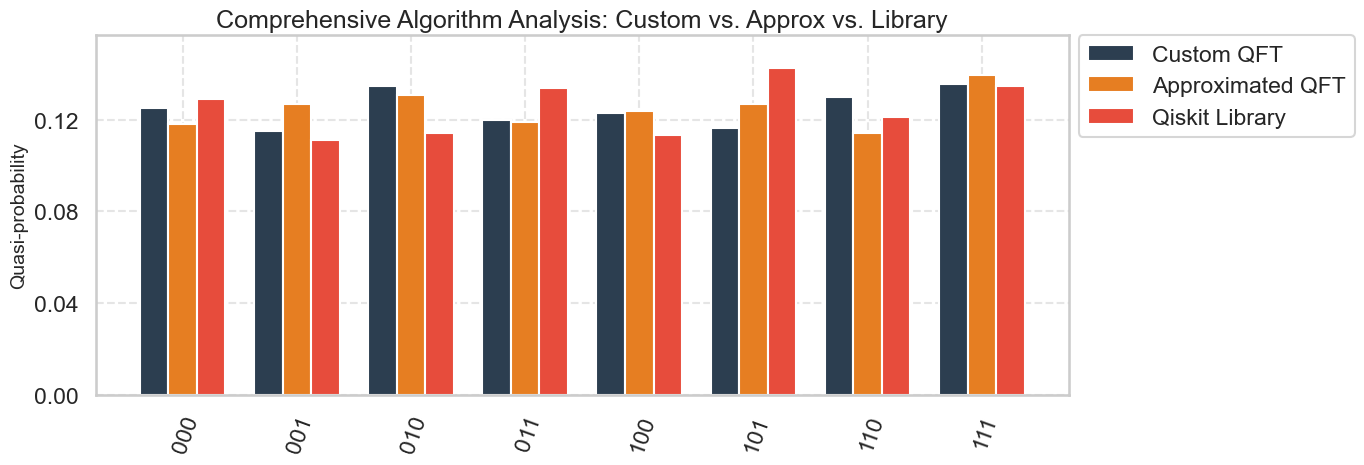

In [264]:
data_to_plot = [p_ideal, p_approx, p_lib]
labels = ['Custom QFT', 'Approximated QFT', 'Qiskit Library']

fig = plot_histogram(
    data_to_plot,
    legend=labels,
    color=['#2c3e50', '#e67e22', '#e74c3c'],
    title="Comprehensive Algorithm Analysis: Custom vs. Approx vs. Library",
    figsize=(14, 5),
    bar_labels=False
)

display(fig)

## 3.6) Complexity Comparison

In [265]:
stats_list = [
    get_circuit_data(qc, "Manual QFT"),
    get_circuit_data(qc_lib, "Library QFT"),
    get_circuit_data(qc_approx, "Approx QFT")
]

df_stats = pd.DataFrame(stats_list)

print("Quantum Fourier Transform: Structural Comparison")
display(df_stats.set_index("Implementation"))

Quantum Fourier Transform: Structural Comparison


,Depth,Total Gates,Gate Breakdown
Implementation,,,
Manual QFT,7,12,"{'h': 3, 'cp': 3, 'measure': 3, 'x': 1, 'swap'..."
Library QFT,6,11,"{'h': 3, 'cp': 3, 'measure': 3, 'x': 1, 'barri..."
Approx QFT,7,12,"{'h': 3, 'cp': 3, 'measure': 3, 'x': 1, 'swap'..."


## 3.7) CPU Timing

In [266]:
# Test sizes (number of qubits)
ns = [15, 20, 25, 30]

# Store execution times and results
cpu_times = []
cpu_results = []

# Ideal simulator (CPU-based)
sim = AerSimulator()

for n in ns:
    # Create quantum circuit with n qubits
    qc = QuantumCircuit(n)

    # Prepare basis state |100...0>
    qc.x(0)

    # Apply Quantum Fourier Transform
    qft(qc, n)

    # Measure all qubits
    qc.measure_all()

    # Measure execution time of simulation
    t = measure_time(qc, sim)
    cpu_times.append(t)

    # Run circuit and store normalized output distribution
    counts_cpu = run_circuit(qc, sim)
    cpu_results.append(normalize(counts_cpu))

# Keep only valid measurements (avoid None values if any)
valid_ns = [n for n, t in zip(ns, cpu_times) if t is not None]
valid_times = [t for t in cpu_times if t is not None]

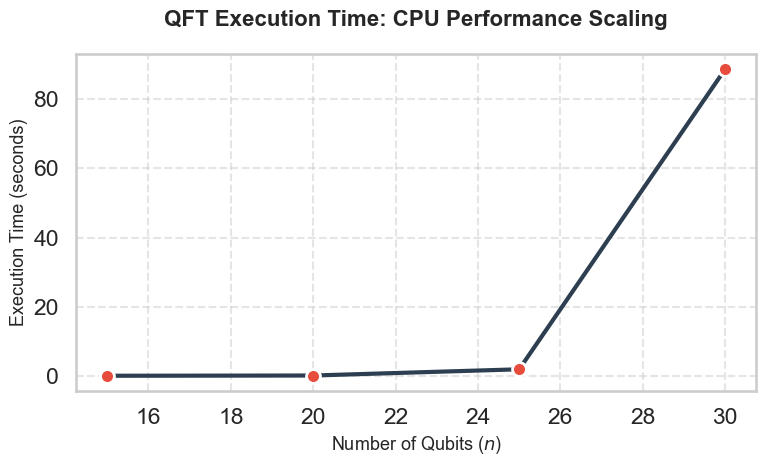


--- Numerical Timing Summary ---


Qubits,15,20,25,30
Time (s),0.068488,0.137583,1.937429,88.616874


In [267]:
df_performance = pd.DataFrame({
    "Qubits": valid_ns,
    "Time (s)": valid_times
})

sns.set_context("talk") # Makes labels/lines easier to read
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})

plt.figure(figsize=(8, 5))

plt.plot(df_performance["Qubits"],
         df_performance["Time (s)"],
         marker='o',
         markersize=10,
         linewidth=3,
         color='#2c3e50', # Deep midnight blue
         markerfacecolor='#e74c3c', # Contrasting red dots
         markeredgewidth=2,
         markeredgecolor='white')

plt.title("QFT Execution Time: CPU Performance Scaling", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Number of Qubits ($n$)", fontsize=13)
plt.ylabel("Execution Time (seconds)", fontsize=13)

plt.tight_layout()
plt.show()

print("\n--- Numerical Timing Summary ---")
display(df_performance.set_index("Qubits").T)

## 3.8) QPU Execution

In [268]:
# Store execution times and results from real hardware
qpu_times = []
qpu_results = []

for n in ns:
    # Create quantum circuit with n qubits
    qc = QuantumCircuit(n)

    # Prepare basis state |100...0>
    qc.x(0)

    # Apply Quantum Fourier Transform
    qft(qc, n)

    # Measure all qubits
    qc.measure_all()

    # Compile circuit for target backend using preset optimization
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(qc)

    # Create Sampler primitive for execution on IBM Runtime
    sampler = SamplerV2(mode=backend)

    # Run job on quantum hardware
    job = sampler.run([isa_circuit], shots=1024)
    result = job.result()

    # Extract timing metadata from job result
    metadata = result[0].metadata
    qpu_time = metadata.get('execution', {}).get('running_time')

    # Fallback to runtime metrics if metadata is missing
    if qpu_time is None:
        metrics = job.metrics()
        qpu_time = metrics["usage"].get("quantum_seconds", 0)

    # Extract measurement counts
    counts_qpu = result[0].data.meas.get_counts()

    # Store results
    qpu_times.append(qpu_time)
    qpu_results.append(normalize(counts_qpu))

# Filter valid timing values
valid_ns = [n for n, t in zip(ns, qpu_times) if t is not None]
valid_times = [t for t in qpu_times if t is not None]

Using backend: <IBMBackend('ibm_fez')>


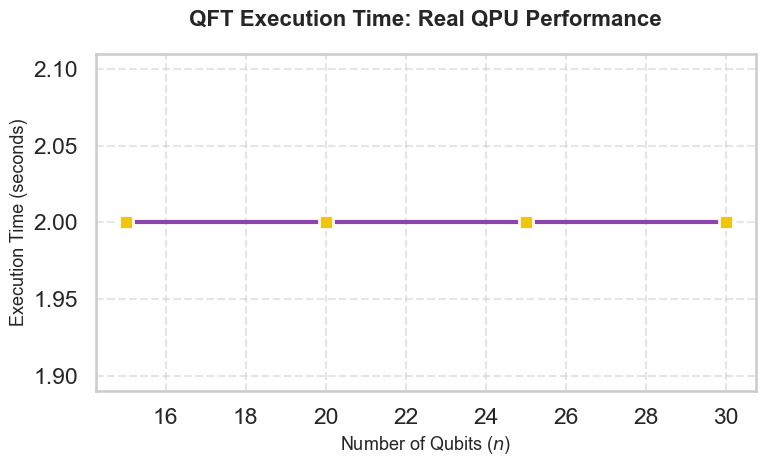


--- QPU Performance Summary (ibm_fez) ---


Qubits,15,20,25,30
Time (s),2,2,2,2


In [269]:
df_qpu_performance = pd.DataFrame({
    "Qubits": valid_ns,
    "Time (s)": valid_times
})

sns.set_context("talk")
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})

plt.figure(figsize=(8, 5))

plt.plot(df_qpu_performance["Qubits"],
         df_qpu_performance["Time (s)"],
         marker='s',
         markersize=10,
         linewidth=3,
         color='#8e44ad',
         markerfacecolor='#f1c40f',
         markeredgewidth=2,
         markeredgecolor='white')

plt.title("QFT Execution Time: Real QPU Performance", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Number of Qubits ($n$)", fontsize=13)
plt.ylabel("Execution Time (seconds)", fontsize=13)

plt.tight_layout()
plt.show()

print(f"\n--- QPU Performance Summary ({backend.name}) ---")
display(df_qpu_performance.set_index("Qubits").T)

# Display selected IBM backend
print("Using backend:", backend)

## 3.9) CPU vs QPU Comparison

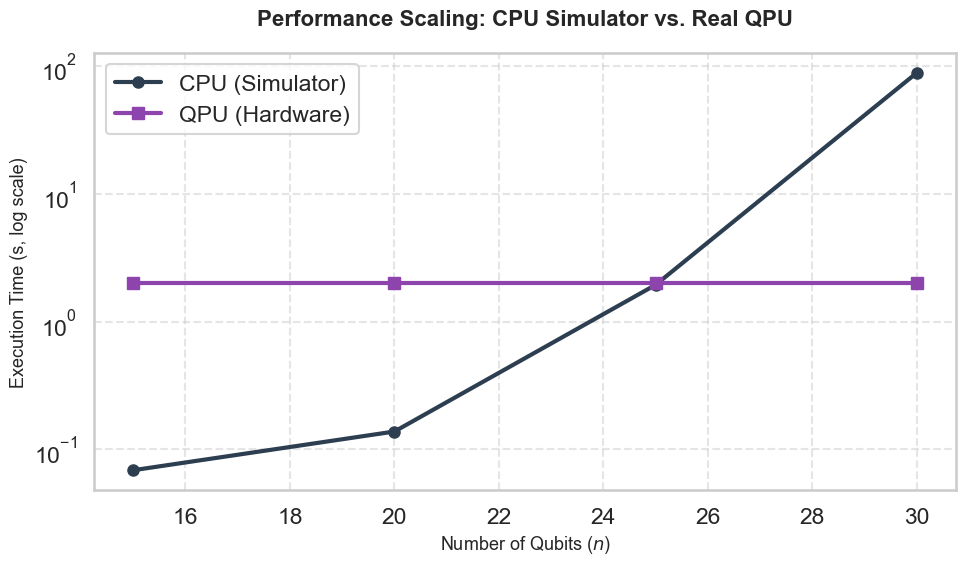

--- Timing Comparison Summary ---


,Qubits,CPU Time (s),QPU Time (s),Ratio (QPU/CPU)
0,15,0.0685,2.00,29.20
1,20,0.1376,2.00,14.54
2,25,1.9374,2.00,1.03
3,30,88.6169,2.00,0.02


In [270]:
df_timing_comp = pd.DataFrame({
    "Qubits": ns,
    "CPU Time (s)": cpu_times,
    "QPU Time (s)": qpu_times
})
df_timing_comp["Ratio (QPU/CPU)"] = df_timing_comp["QPU Time (s)"] / df_timing_comp["CPU Time (s)"]

sns.set_context("talk")
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})
plt.figure(figsize=(10, 6))

plt.plot(ns, cpu_times, marker='o', markersize=8, linewidth=3, label="CPU (Simulator)", color='#2c3e50')
plt.plot(ns, qpu_times, marker='s', markersize=8, linewidth=3, label="QPU (Hardware)", color='#8e44ad')

plt.yscale('log') # Log scale is recommended here to see the different scaling slopes
plt.xlabel("Number of Qubits ($n$)", fontsize=13)
plt.ylabel("Execution Time (s, log scale)", fontsize=13)
plt.title("Performance Scaling: CPU Simulator vs. Real QPU", fontsize=16, fontweight='bold', pad=20)
plt.legend()
plt.tight_layout()
plt.show()

print("--- Timing Comparison Summary ---")
display(df_timing_comp.style.format({"CPU Time (s)": "{:.4f}", "QPU Time (s)": "{:.2f}", "Ratio (QPU/CPU)": "{:.2f}"})
                 .background_gradient(subset=["Ratio (QPU/CPU)"], cmap="YlGnBu"))